# Part 1 – Visualization
**Group 2 · Season 2023 (January 1 to May 31)**

Between January and May 2023, heavy rains hit Peru and the government declared states of emergency in many departments. In Assignment 2 we collected two things for each department: how many **emergency declarations** it received (scraped from gob.pe) and how much it **rained** (from the Open-Meteo API). We joined both in one table: `tabla_final.csv`.

Our question is simple: **does the State declare emergencies where it rains the most?**

Nobody reads tables: people look at charts. In this notebook we use **Plotly Express** to answer the question with:

1. A **bar chart**: which departments received the most declarations.
2. A **scatter plot**: rainfall vs. declarations.
3. A **histogram**: how unequal the rainfall was across the country.
4. A **quick check** that the charts show the same as the table.
5. **Extra 1**: the departments that got more rain but fewer declarations.
6. **Extra 2**: when the declarations were published, month by month.

In [5]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Render every chart twice: interactive for Jupyter and a static PNG,
# so the charts are also visible on GitHub (same as in Assignment 2).
pio.renderers.default = "plotly_mimetype+png"

## 1. Load the data

In [6]:
tabla = pd.read_csv("datos/tabla_final.csv", encoding="utf-8-sig", dtype={"ubigeo": str})

tabla.shape

(25, 9)

In [7]:
tabla.head()

,ubigeo,departamento,declaratorias,prorrogas,lluvia_total_mm,dias_lluvia_fuerte,capital,latitud,longitud
0,01,Amazonas,3,1,414.6,3,Chachapoyas,-6.23169,-77.86903
1,02,Áncash,6,1,1145.8,9,Huaraz,-9.52614,-77.52869
2,03,Apurímac,1,0,726.2,3,Abancay,-13.63426,-72.88380
3,04,Arequipa,4,0,362.0,1,Arequipa,-16.39899,-71.53747
4,05,Ayacucho,5,1,498.4,2,Ayacucho,-13.16380,-74.22345


## 2. Question and columns

**Question:** Does the State declare emergencies where it rains the most?

We use these columns:

| Column | Meaning |
|---|---|
| `departamento` | Department name |
| `declaratorias` | Number of emergency declarations due to rain (Jan–May 2023) |
| `lluvia_total_mm` | Total rainfall in the season, in mm, measured at the department capital |
| `dias_lluvia_fuerte` | Days with 20 mm of rain or more |

Sources: emergency decrees from the PCM legal norms on gob.pe (scraped in Assignment 2), and rainfall from the Open-Meteo historical weather API.

**Note:** each row is one department for the whole season. We can compare departments, but not days: Assignment 2 saved only the **season total** of rain, not the daily rainfall. So we cannot measure how many days it took to declare an emergency. We can only see the **month** each decree was published (Extra 2).

In [8]:
fuente = "Source: PCM emergency decrees (gob.pe) and Open-Meteo, Jan-May 2023. Own elaboration."

## 3. Bar chart: which departments got the most declarations?

Horizontal bars, because department names are long. `sort_values` puts them in order.

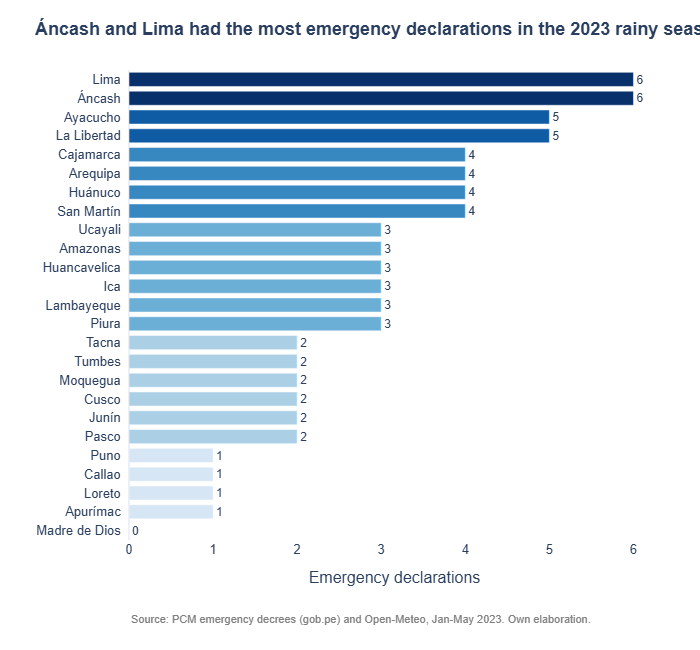

In [11]:
fig = px.bar(tabla.sort_values("declaratorias"),
             x="declaratorias", y="departamento", orientation="h",
             color="declaratorias", color_continuous_scale="Blues",
             text="declaratorias",
             labels={"declaratorias": "Emergency declarations", "departamento": ""},
             title="<b>Áncash and Lima had the most emergency declarations in the 2023 rainy season</b>",
             height=650)
fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_layout(
    coloraxis_showscale=False,
    template="plotly_white",
    font=dict(family="Arial", size=13),
    title_font_size=18,
    bargap=0.25,
    margin=dict(l=10, r=40, t=70, b=110),
    xaxis=dict(showgrid=False),
    yaxis=dict(ticksuffix="  "),
    annotations=[dict(
        text=fuente, showarrow=False, xref="paper", yref="paper",
        x=0, y=-0.15, yanchor="top", font=dict(size=11, color="gray"),
    )],
)
fig.show()

The chart shows the number of emergency declarations received by each department between January and May 2023, sorted from lowest to highest so that the ranking can be read at a glance. Horizontal bars were used because department names are long, and the exact value is displayed at the end of each bar. Áncash and Lima received the most declarations (6 each), followed by Ayacucho and La Libertad (5 each). At the other end, Madre de Dios received none, a result we return to in the scatter plot.